# Student Performance Analytics

## Project Overview

This project analyzes student performance data to investigate factors associated with mathematics achievement and to evaluate whether student characteristics can be used to identify students with relatively high mathematics performance.

The analysis combines:

- Exploratory Data Analysis (EDA)
- Descriptive statistics
- Hypothesis testing
- Effect-size analysis
- Confidence intervals
- Machine learning classification
- Model evaluation
- Explainable AI using SHAP

## Objective

The primary objectives are:

1. Explore patterns in student academic performance.
2. Investigate whether completion of a test preparation course is associated with mathematics scores.
3. Identify characteristics associated with differences in student performance.
4. Evaluate whether student characteristics can predict relatively high mathematics performance.
5. Compare Logistic Regression and Random Forest models.
6. Interpret model predictions using feature importance and SHAP.

> Important: Observational relationships identified in this dataset should not be interpreted as causal effects.

## Research Questions

### RQ1
Is mathematics performance different between students who completed the test preparation course and those who did not?

### RQ2
What demographic, socioeconomic, and educational characteristics are associated with student performance?

### RQ3
Can student characteristics be used to predict relatively high mathematics performance?

### RQ4
Which classification model performs better for this prediction task: Logistic Regression or Random Forest?

### RQ5
Which features contribute most to the model's predictions?

In [61]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Explainable AI
import shap

# Reproducibility
RANDOM_STATE = 42

Load the Dataset

In [62]:
df = pd.read_csv("../data/studentsPerformance.csv")

In [63]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Dataset Description

The dataset contains 1,000 student records and 8 variables describing demographic characteristics, socioeconomic factors, test preparation, and academic scores.

| Feature | Description | Type |
|---|---|---|
| gender | Student gender | Categorical |
| race/ethnicity | Student race/ethnicity group | Categorical |
| parental level of education | Highest parental education level | Categorical |
| lunch | Lunch program category | Categorical |
| test preparation course | Test preparation completion status | Categorical |
| math score | Mathematics examination score | Numerical |
| reading score | Reading examination score | Numerical |
| writing score | Writing examination score | Numerical |

## 3. Understanding the Dataset

Check Dataset Size

In [64]:
df.shape

(1000, 8)

In [65]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

Get Dataset Information

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [67]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 4. Data Quality Assessment


In [68]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


Duplicate rows:
0


In [69]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

### Checking Potentially Unusual Values

The mathematics score has a minimum value of 0. Before making any data-cleaning decision, we investigate these observations to determine whether they represent valid records or possible data-quality issues.

In [72]:
zero_math = df[df["math score"] == 0]

print(f"Number of students with math score = 0: {len(zero_math)}")

zero_math

Number of students with math score = 0: 1


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10


In [73]:
zero_math

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10


In [75]:
score_columns = ["math score", "reading score", "writing score"]

for col in score_columns:
    invalid_scores = df[(df[col] < 0) | (df[col] > 100)]
    
    print(f"{col}: {len(invalid_scores)} invalid values")

math score: 0 invalid values
reading score: 0 invalid values
writing score: 0 invalid values


### Decision on Zero Mathematics Score

Only one student has a mathematics score of 0. The same student also has very low reading and writing scores (17 and 10), suggesting that the value may represent a genuine low-performance observation rather than a data-entry error.

Therefore, the observation is retained in the dataset. No evidence was found that the value represents a missing or invalid entry.

### Data Quality Summary

The dataset contains no missing values or duplicate records. All mathematics, reading, and writing scores fall within the valid range of 0–100.

One student has a mathematics score of 0. After examining the student's other academic scores, the observation was considered plausible and was retained.

Therefore, no observations were removed during data-quality assessment.

In [ ]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [ ]:
df.sample(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
958,female,group D,high school,standard,none,45,63,59
889,male,group D,high school,free/reduced,none,44,51,48
856,male,group B,some college,free/reduced,none,75,68,65
31,female,group B,some college,standard,none,63,65,61
217,female,group C,high school,free/reduced,none,34,42,39


Exploratory Data Analysis(EDA)

## 5. Exploratory Data Analysis

Exploratory Data Analysis is used to understand the distribution of academic scores and examine how demographic, socioeconomic, and educational factors are associated with student performance.

The analysis focuses on:

- Distribution of mathematics, reading, and writing scores
- Student demographic characteristics
- Socioeconomic factors
- Test preparation
- Differences in average performance across groups
- Relationships between academic scores

### 5.1 Distribution of Academic Scores

The first step of EDA is to examine how mathematics, reading, and writing scores are distributed across the students.

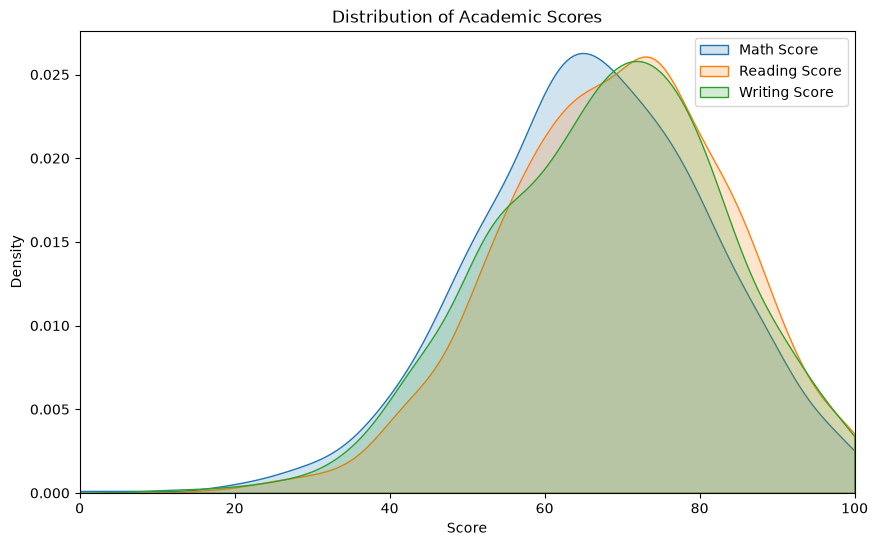

In [77]:
score_columns = ['math score', 'reading score', 'writing score']

plt.figure(figsize=(10, 6))

for column in score_columns:
    sns.kdeplot(
        data=df,
        x=column,
        label=column.title(),
        fill=True,
        alpha=0.2,
        clip=(0, 100)
    )

plt.title('Distribution of Academic Scores')
plt.xlabel('Score')
plt.ylabel('Density')
plt.xlim(0, 100)
plt.legend()
plt.show()

### Interpretation

The three academic scores show broadly similar distributions, with reading and writing scores generally centered at slightly higher values than mathematics scores. Mathematics also shows a wider lower tail because of the presence of a very low score.

The distributions provide an initial understanding of overall student performance before examining differences across demographic, socioeconomic, and educational groups.

### 5.2 Academic Score Comparison

Box plots are used to compare the central tendency, spread, and potential outliers of mathematics, reading, and writing scores.

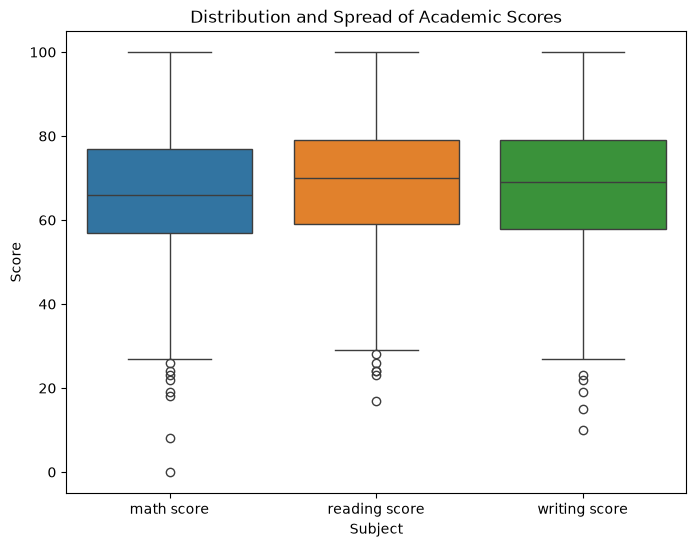

In [78]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df[['math score', 'reading score', 'writing score']]
)

plt.title('Distribution and Spread of Academic Scores')
plt.xlabel('Subject')
plt.ylabel('Score')
plt.show()

### Interpretation

The box plots show that reading and writing scores have slightly higher median values than mathematics scores. The overall spread of scores is broadly similar across the three subjects.

Several low-score observations appear as potential outliers, particularly in mathematics. These observations were not removed because they fall within the valid score range and may represent genuine differences in student performance.

Overall, the distributions suggest that student performance varies across subjects, while the three score distributions remain broadly comparable.

### 5.3 Student Distribution by Gender

The distribution of students by gender is examined to understand the composition of the dataset before comparing academic performance across gender groups.

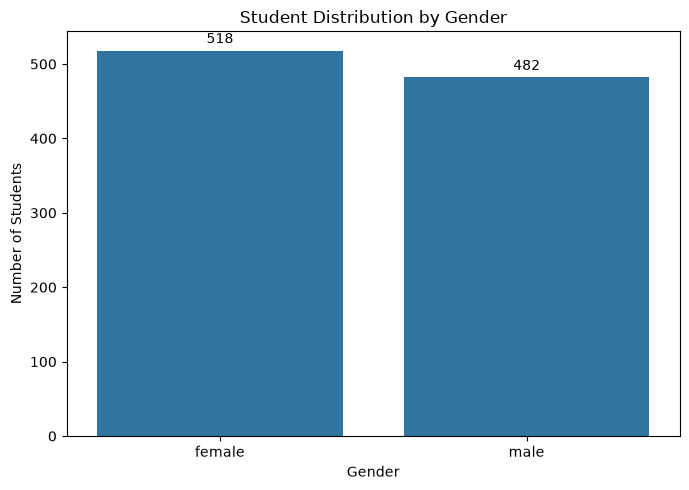

In [80]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title('Student Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains students from both gender groups with a relatively similar representation. This provides a reasonable basis for comparing academic performance across gender groups without one group being overwhelmingly dominant in the dataset.

### 5.4 Academic Performance by Gender

The average mathematics, reading, and writing scores are compared across gender groups to examine differences in academic performance.

In [82]:
gender_scores = (
    df.groupby('gender')[['math score', 'reading score', 'writing score']]
      .mean()
      .reset_index()
)

gender_scores

,gender,math score,reading score,writing score
0,female,63.633205,72.608108,72.467181
1,male,68.728216,65.473029,63.311203


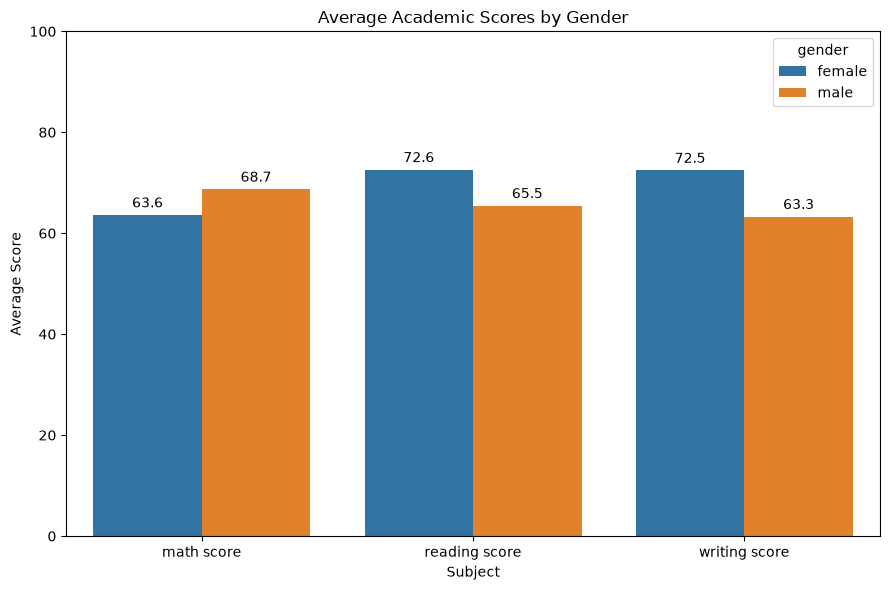

In [83]:
gender_scores_melted = gender_scores.melt(
    id_vars='gender',
    var_name='Subject',
    value_name='Average Score'
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=gender_scores_melted,
    x='Subject',
    y='Average Score',
    hue='gender'
)

plt.title('Average Academic Scores by Gender')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The average academic scores show noticeable differences across gender groups.

- Male students have a higher average mathematics score (68.7) than female students (63.6).
- Female students have higher average reading (72.6) and writing (72.5) scores than male students (65.5 and 63.3, respectively).
- The largest observed difference is in writing scores, where the female group scores approximately 9.2 points higher on average.

These results describe differences within this dataset and should not be interpreted as evidence that gender causes differences in academic performance.

### 5.5 Student Distribution by Race/Ethnicity

The distribution of students across race/ethnicity groups is examined to understand the composition of the dataset before comparing academic performance across these groups.

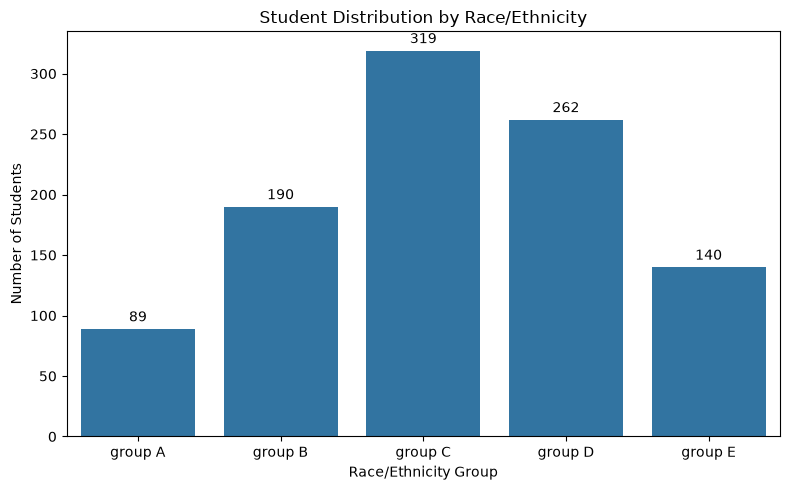

In [84]:
race_counts = df['race/ethnicity'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=race_counts.index,
    y=race_counts.values
)

plt.title('Student Distribution by Race/Ethnicity')
plt.xlabel('Race/Ethnicity Group')
plt.ylabel('Number of Students')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains students from five race/ethnicity groups, but their representation is not evenly distributed.

- Group C has the largest representation with 319 students.
- Group D follows with 262 students.
- Group B contains 190 students.
- Group E contains 140 students.
- Group A has the smallest representation with 89 students.

Because the group sizes differ substantially, comparisons of academic performance across race/ethnicity groups should consider these differences in sample size. The distribution itself does not imply differences in academic ability or performance.

### 5.6 Academic Performance by Race/Ethnicity

Average mathematics, reading, and writing scores are compared across race/ethnicity groups to examine differences in academic performance within the dataset.

In [85]:
race_scores = (
    df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']]
      .mean()
      .reset_index()
)

race_scores

,race/ethnicity,math score,reading score,writing score
0,group A,61.629213,64.674157,62.674157
1,group B,63.452632,67.352632,65.600000
2,group C,64.463950,69.103448,67.827586
3,group D,67.362595,70.030534,70.145038
4,group E,73.821429,73.028571,71.407143


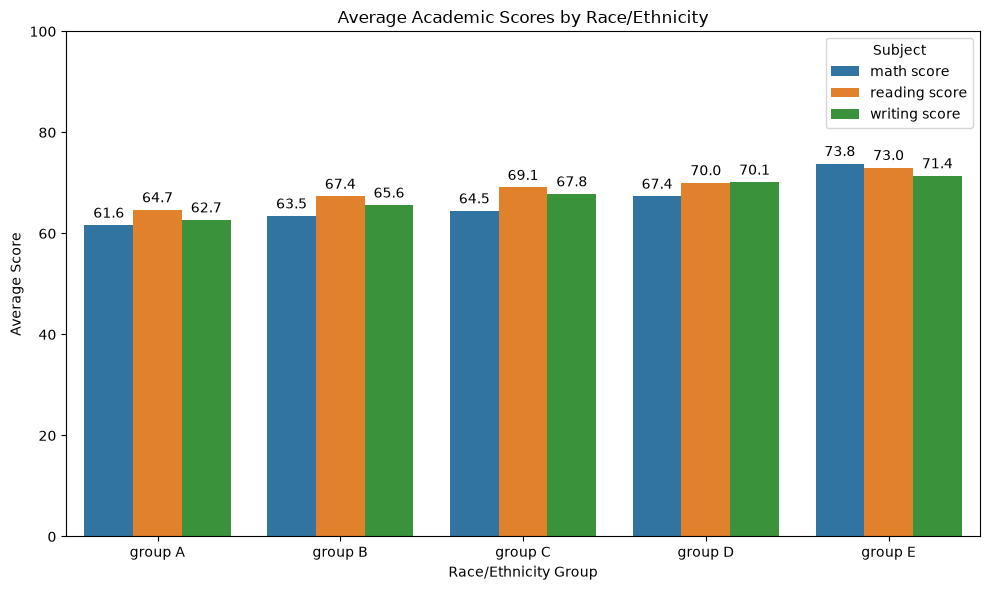

In [86]:
race_scores_melted = race_scores.melt(
    id_vars='race/ethnicity',
    var_name='Subject',
    value_name='Average Score'
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=race_scores_melted,
    x='race/ethnicity',
    y='Average Score',
    hue='Subject'
)

plt.title('Average Academic Scores by Race/Ethnicity')
plt.xlabel('Race/Ethnicity Group')
plt.ylabel('Average Score')
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The average academic scores vary across race/ethnicity groups in the dataset.

- Group E has the highest average mathematics score (73.8) and reading score (73.0).
- Group E also has the highest average writing score (71.4), followed by Group D (70.1).
- Group A has the lowest average mathematics score (61.6) and writing score (62.7).
- Across all five groups, reading scores are generally higher than mathematics scores.
- The observed differences are descriptive and do not establish that race/ethnicity causes differences in academic performance.
- Since the groups have unequal sample sizes, comparisons should be interpreted with consideration of the underlying group representation.

### 5.7 Student Distribution by Parental Education

The distribution of students across parental education levels is examined to understand the educational background represented in the dataset.

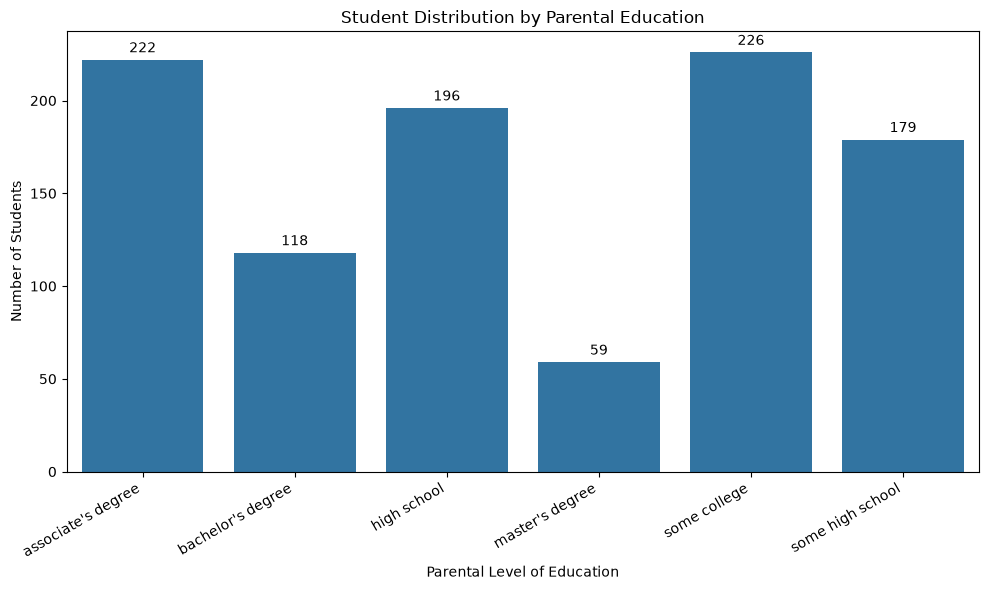

In [87]:
parent_education_counts = (
    df['parental level of education']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=parent_education_counts.index,
    y=parent_education_counts.values
)

plt.title('Student Distribution by Parental Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Number of Students')

plt.xticks(rotation=30, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains students from six parental education categories, with a total of 1,000 students.

- Some college is the most common category, representing 226 students.
- An associate's degree is the second most common category, with 222 students.
- A high school education accounts for 196 students.
- Some high school represents 179 students.
- Bachelor's degree holders account for 118 students.
- Master's degree is the least represented category, with 59 students.

Overall, the distribution is concentrated in the some college, associate's degree, and high school categories, while bachelor's and master's degree categories have fewer observations.

### 5.8 Academic Performance by Parental Education

Average mathematics, reading, and writing scores are compared across parental education levels to examine whether academic performance varies with parental educational background.

In [88]:
parent_education_scores = (
    df.groupby('parental level of education')
      [['math score', 'reading score', 'writing score']]
      .mean()
      .reset_index()
)

parent_education_scores

,parental level of education,math score,reading score,writing score
0,associate's degree,67.882883,70.927928,69.896396
1,bachelor's degree,69.389831,73.000000,73.381356
2,high school,62.137755,64.704082,62.448980
3,master's degree,69.745763,75.372881,75.677966
4,some college,67.128319,69.460177,68.840708
5,some high school,63.497207,66.938547,64.888268


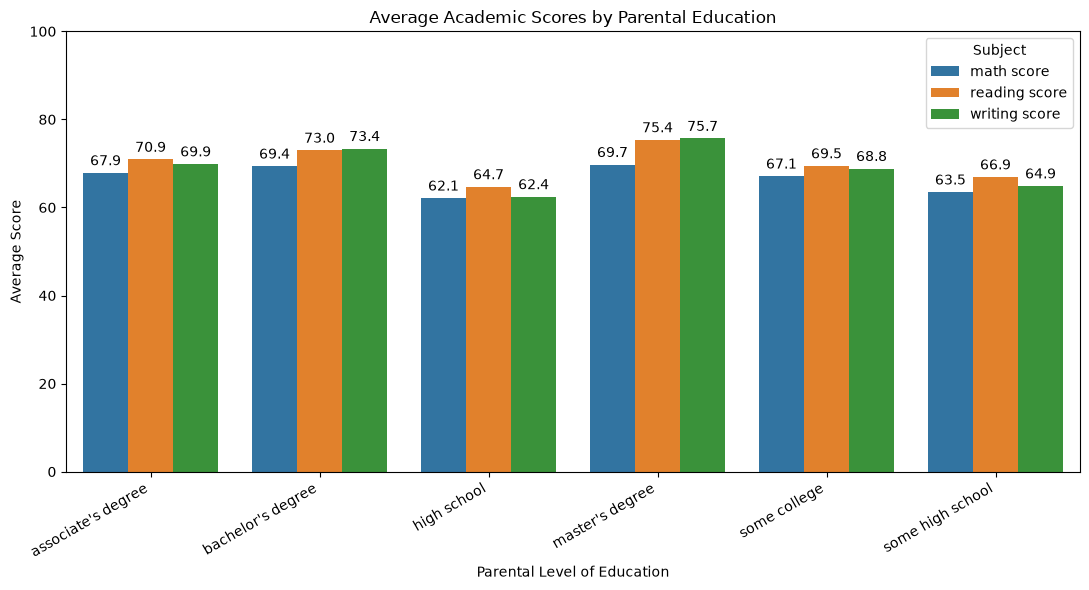

In [89]:
parent_education_melted = parent_education_scores.melt(
    id_vars='parental level of education',
    var_name='Subject',
    value_name='Average Score'
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=parent_education_melted,
    x='parental level of education',
    y='Average Score',
    hue='Subject'
)

plt.title('Average Academic Scores by Parental Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.ylim(0, 100)

plt.xticks(rotation=30, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

Average academic performance varies across parental education levels in the dataset.

- Students whose parents have a master's degree have the highest average reading (75.4) and writing (75.7) scores, while their average mathematics score is also relatively high (69.7).
- Students whose parents have a bachelor's degree also show relatively high average performance, with mathematics, reading, and writing scores of 69.4, 73.0, and 73.4, respectively.
- Students whose parents have a high school or some high school education generally have lower average scores across the three subjects.
- Reading and writing scores are consistently higher than mathematics scores across all parental education categories.
- Reading and writing performance follows a similar pattern across parental education groups, with relatively small differences between the two subjects.
- These results indicate an association between parental education level and average student performance within this dataset. They do not establish that parental education causes differences in academic performance.

### 5.9 Student Distribution by Lunch Status

The distribution of students by lunch status is examined as an indicator of socioeconomic background represented in the dataset.

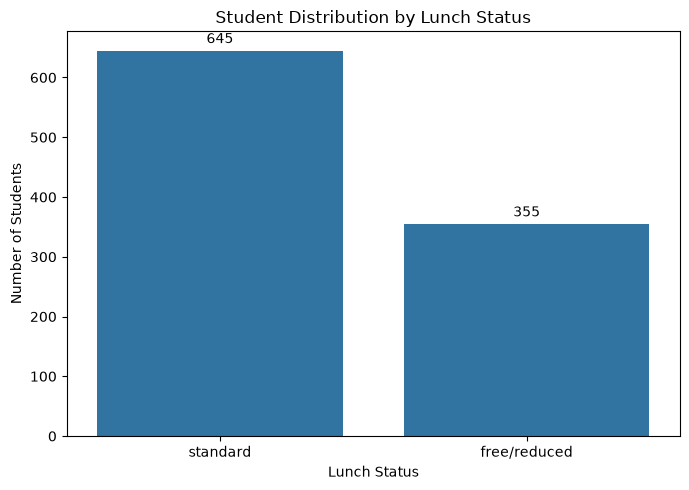

In [90]:
lunch_counts = df['lunch'].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=lunch_counts.index,
    y=lunch_counts.values
)

plt.title('Student Distribution by Lunch Status')
plt.xlabel('Lunch Status')
plt.ylabel('Number of Students')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains 1,000 students with two lunch-status categories.

- 645 students (64.5%) have standard lunch status.
- 355 students (35.5%) have free or reduced-price lunch status.
- Standard lunch is more common, representing nearly two-thirds of the dataset.
- Free or reduced-price lunch represents approximately one-third of the students.

The unequal group sizes should be considered when comparing academic performance across lunch-status categories. Lunch status is treated as an indicator of socioeconomic background rather than a direct measure of socioeconomic status.

### 5.10 Academic Performance by Lunch Status

Average mathematics, reading, and writing scores are compared across lunch-status categories to examine differences in academic performance associated with socioeconomic background.

In [91]:
lunch_scores = (
    df.groupby('lunch')[['math score', 'reading score', 'writing score']]
      .mean()
      .reset_index()
)

lunch_scores

,lunch,math score,reading score,writing score
0,free/reduced,58.921127,64.653521,63.022535
1,standard,70.034109,71.654264,70.823256


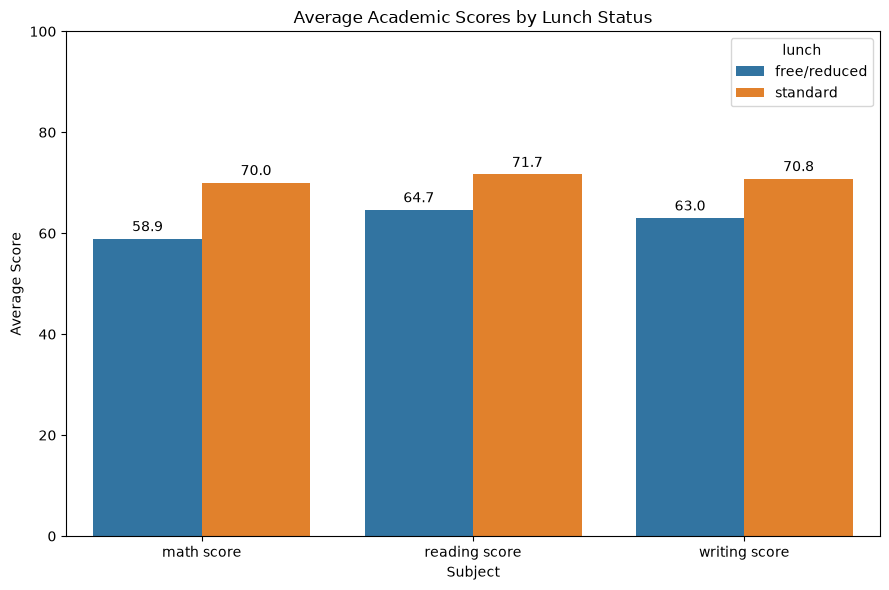

In [92]:
lunch_scores_melted = lunch_scores.melt(
    id_vars='lunch',
    var_name='Subject',
    value_name='Average Score'
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=lunch_scores_melted,
    x='Subject',
    y='Average Score',
    hue='lunch'
)

plt.title('Average Academic Scores by Lunch Status')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The average academic scores show a clear difference between the two lunch-status groups.

- Students with standard lunch status have higher average scores across all three subjects.
- The largest difference occurs in mathematics, where the standard-lunch group averages 70.0 compared with 58.9 for the free/reduced-lunch group, a difference of approximately 11.1 points.
- In reading, the standard-lunch group averages 71.7 compared with 64.7 for the free/reduced-lunch group, a difference of approximately 7.0 points.
- In writing, the standard-lunch group averages 70.8 compared with 63.0 for the free/reduced-lunch group, a difference of approximately 7.8 points.
- Both groups show a similar pattern in which reading and writing scores are generally higher than mathematics scores.
- These results indicate an association between lunch status and academic performance within this dataset. They do not establish that lunch status or socioeconomic background causes differences in academic performance.

### 5.11 Student Distribution by Test Preparation Course

The distribution of students who completed or did not complete the test preparation course is examined to understand participation in the program.

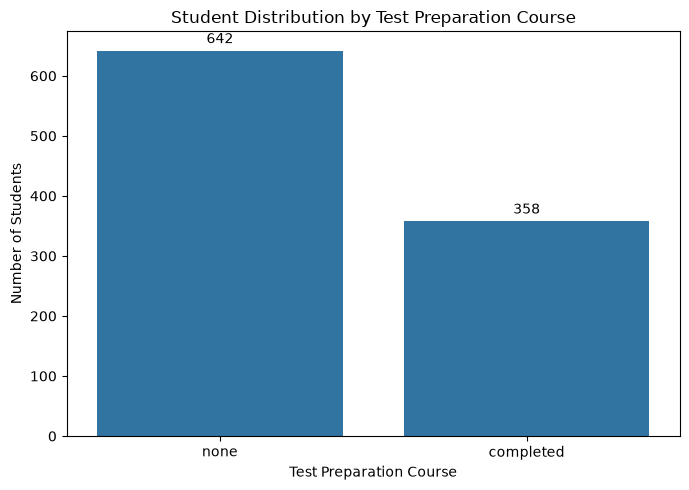

In [93]:
test_prep_counts = df['test preparation course'].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=test_prep_counts.index,
    y=test_prep_counts.values
)

plt.title('Student Distribution by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Number of Students')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains 1,000 students across two test preparation categories.

- 642 students (64.2%) did not complete a test preparation course.
- 358 students (35.8%) completed a test preparation course.
- Students who did not complete the course represent the larger group, accounting for nearly two-thirds of the dataset.
- Students who completed the course represent approximately one-third of the dataset.

The unequal group sizes should be considered when comparing academic performance between the two groups.

### 5.12 Academic Performance by Test Preparation Course

Average mathematics, reading, and writing scores are compared between students who completed the test preparation course and those who did not.

In [94]:
test_prep_scores = (
    df.groupby('test preparation course')
      [['math score', 'reading score', 'writing score']]
      .mean()
      .reset_index()
)

test_prep_scores

,test preparation course,math score,reading score,writing score
0,completed,69.695531,73.893855,74.418994
1,none,64.077882,66.534268,64.504673


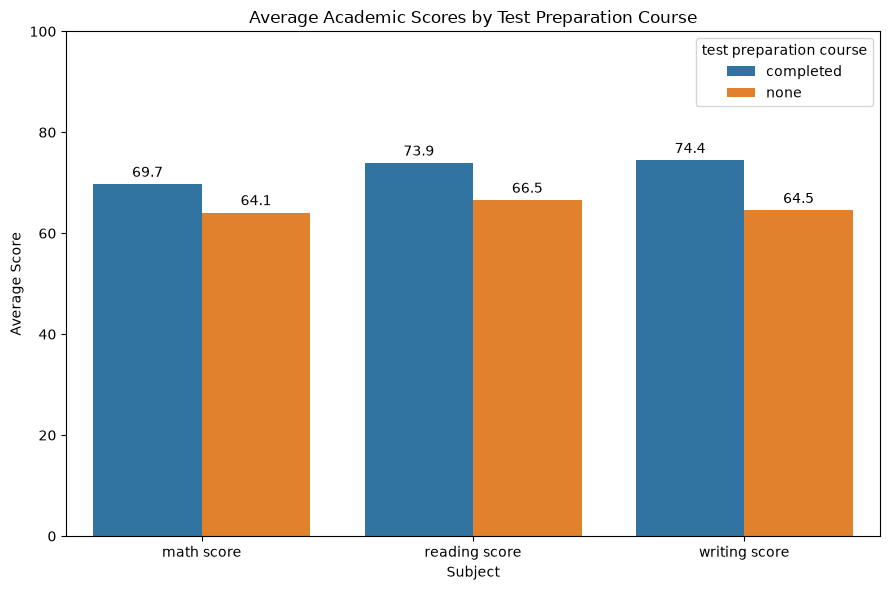

In [95]:
test_prep_scores_melted = test_prep_scores.melt(
    id_vars='test preparation course',
    var_name='Subject',
    value_name='Average Score'
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=test_prep_scores_melted,
    x='Subject',
    y='Average Score',
    hue='test preparation course'
)

plt.title('Average Academic Scores by Test Preparation Course')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()


Interpretation

The average academic scores are higher for students who completed the test preparation course across all three subjects.
Students who completed the course scored 69.7 in mathematics, compared with 64.1 for students who did not take the course.
- In reading, the completed group scored 73.9, compared with 66.5 for the no-preparation group.
- In writing, the completed group scored 74.4, compared with 64.5, showing the largest difference of approximately 9.9   points.

Overall, students who completed the test preparation course had higher average scores in all three subjects.
These results indicate an association between test preparation and higher academic performance in this dataset. However, they do not establish that test preparation directly caused the higher scores.

Filtering Data

In [ ]:
#students who scores greater than 90

df[df['math score'] >90]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
34,male,group E,some college,standard,none,97,87,82
104,male,group C,some college,standard,completed,98,86,90
114,female,group E,bachelor's degree,standard,completed,99,100,100
121,male,group B,associate's degree,standard,completed,91,89,92
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
171,male,group E,some high school,standard,none,94,88,78
179,female,group D,some high school,standard,completed,97,100,100
233,male,group E,some high school,standard,none,92,87,78
263,female,group E,high school,standard,none,99,93,90


In [ ]:
#students wo completed the test preparation course

df[df['test preparation course'] == 'completed']

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group C,some college,standard,completed,69,90,88
6,female,group B,some college,standard,completed,88,95,92
8,male,group D,high school,free/reduced,completed,64,64,67
13,male,group A,some college,standard,completed,78,72,70
18,male,group C,master's degree,free/reduced,completed,46,42,46
...,...,...,...,...,...,...,...,...
990,male,group E,high school,free/reduced,completed,86,81,75
991,female,group B,some high school,standard,completed,65,82,78
995,female,group E,master's degree,standard,completed,88,99,95
997,female,group C,high school,free/reduced,completed,59,71,65


In [ ]:
#Female students

df[df['gender'] == 'female']

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
...,...,...,...,...,...,...,...,...
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
995,female,group E,master's degree,standard,completed,88,99,95
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
#Students who scored above 90 in all three subjects

df[
    (df['math score'] >90)&
    (df['reading score'] >90)&
    (df['writing score']>90)
]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
114,female,group E,bachelor's degree,standard,completed,99,100,100
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100
451,female,group E,some college,standard,none,100,92,97
458,female,group E,bachelor's degree,standard,none,100,100,100
546,female,group A,some high school,standard,completed,92,100,97
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100
571,male,group A,bachelor's degree,standard,none,91,96,92
594,female,group C,bachelor's degree,standard,completed,92,100,99


In [ ]:
#count students

len(df[df['math score'] >90])

50

Correlation Analysis

In [ ]:
#correlation calculation

df[['math score', 'reading score', 'writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


Let's Draw a Correlation Heatmap

In [ ]:
import matplotlib.pyplot as plt

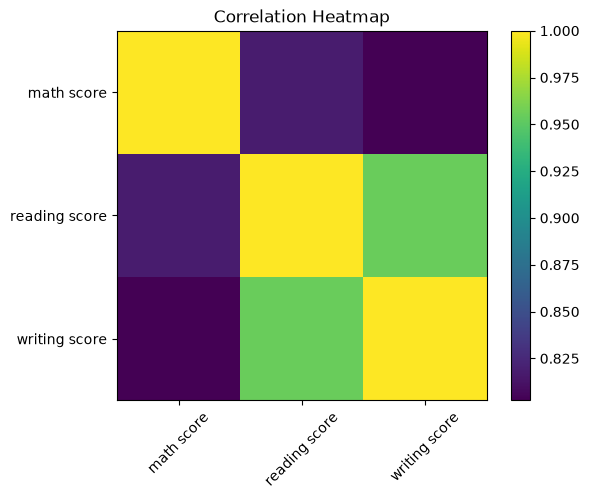

In [ ]:
corr =df[['math score', 'reading score', 'writing score']].corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
corr.columns, rotation=45)

plt.yticks(range(len(corr.columns)),
corr.columns)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
# Statistical Hypothesis Testing
# Question: Does test preparation significantly affect math scores?

from scipy.stats import ttest_ind

# Separate math scores into two groups
completed = df[df['test preparation course'] == 'completed']['math score']
not_completed = df[df['test preparation course'] == 'none']['math score']

# Perform independent samples t-test
t_stat, p_value = ttest_ind(completed, not_completed, equal_var=False)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Result: The difference is statistically significant.")
else:
    print("Result: The difference is not statistically significant.")

T-statistic: 5.787
P-value: 0.0
Result: The difference is statistically significant.


In [ ]:
# Calculate mean scores for both groups

completed_mean = completed.mean()
not_completed_mean = not_completed.mean()

print("Average Math Score - Completed:", round(completed_mean, 2))
print("Average Math Score - Not Completed:", round(not_completed_mean, 2))

# Calculate the difference
difference = completed_mean - not_completed_mean

print("Difference in Average Math Score:", round(difference, 2))

Average Math Score - Completed: 69.7
Average Math Score - Not Completed: 64.08
Difference in Average Math Score: 5.62


## Statistical Hypothesis Testing

### Research Question

Does completing the test preparation course significantly affect students' mathematics scores?

### Hypotheses

- **Null Hypothesis (H₀):** There is no significant difference in mathematics scores between the two groups.
- **Alternative Hypothesis (H₁):** There is a significant difference in mathematics scores between the two groups.

### Statistical Test

An independent samples t-test was used to compare the mathematics scores of students who completed the test preparation course with those who did not.

A significance level of α = 0.05 was used.

In [ ]:
from scipy.stats import ttest_ind

completed = df[df['test preparation course'] == 'completed']['math score']
not_completed = df[df['test preparation course'] == 'none']['math score']

t_stat, p_value = ttest_ind(
    completed,
    not_completed,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: The difference is statistically significant.")
else:
    print("Result: The difference is not statistically significant.")

T-statistic: 5.787
P-value: 1.0425616722069541e-08
Result: The difference is statistically significant.


### Result

The independent samples t-test produced a statistically significant result (p < 0.05). Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference in mathematics scores between students who completed the test preparation course and those who did not.

## Effect Size Analysis

Statistical significance tells us whether the difference between the two groups is unlikely to be due to random chance. However, it does not tell us how large or meaningful the difference is.

Therefore, we calculate the mean difference between students who completed the test preparation course and those who did not.

In [ ]:
# Calculate average math scores

completed_mean = completed.mean()
not_completed_mean = not_completed.mean()

# Calculate mean difference
difference = completed_mean - not_completed_mean

print("Average Math Score - Completed:", round(completed_mean, 2))
print("Average Math Score - Not Completed:", round(not_completed_mean, 2))
print("Difference in Average Math Score:", round(difference, 2))

Average Math Score - Completed: 69.7
Average Math Score - Not Completed: 64.08
Difference in Average Math Score: 5.62


## Confidence Interval Analysis

A 95% confidence interval is calculated to estimate the range of the difference in average mathematics scores between students who completed the test preparation course and those who did not.

This provides additional information about the uncertainty around the estimated difference.

In [ ]:
from scipy.stats import t

# Sample sizes
n1 = len(completed)
n2 = len(not_completed)

# Standard errors
se1 = completed.std(ddof=1) / (n1 ** 0.5)
se2 = not_completed.std(ddof=1) / (n2 ** 0.5)

# Standard error of the difference
se_diff = (se1**2 + se2**2) ** 0.5

# Degrees of freedom using Welch-Satterthwaite equation
df_welch = (se1**2 + se2**2)**2 / (
    (se1**4 / (n1 - 1)) + (se2**4 / (n2 - 1))
)

# 95% confidence interval
t_critical = t.ppf(0.975, df_welch)

lower = difference - t_critical * se_diff
upper = difference + t_critical * se_diff

print("Mean Difference:", round(difference, 2))
print("95% Confidence Interval:", 
      round(lower, 2), "to", round(upper, 2))

Mean Difference: 5.62
95% Confidence Interval: 3.71 to 7.52


## Mathematics Score Comparison

The following visualization compares the average mathematics scores of students who completed the test preparation course with those who did not.

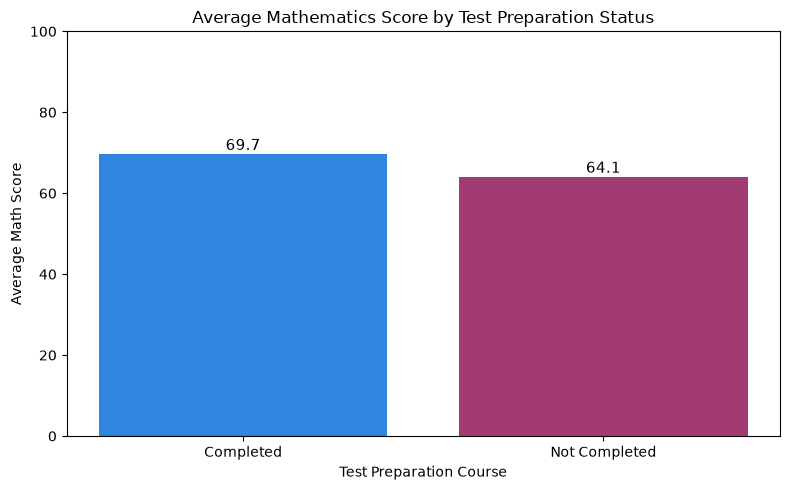

In [ ]:
import matplotlib.pyplot as plt

groups = ['Completed', 'Not Completed']
means = [completed_mean, not_completed_mean]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    groups,
    means,
    color=['#2E86DE', '#A23B72']
)

plt.title('Average Mathematics Score by Test Preparation Status')
plt.ylabel('Average Math Score')
plt.xlabel('Test Preparation Course')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}',
        ha='center',
        fontsize=11
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Machine Learning: Predicting High Mathematics Performance

### Research Question

Can we predict whether a student will achieve a high mathematics score based on their demographic characteristics, parental education, lunch type, and test preparation?

### Target Variable

A student is classified as a **high performer** if their mathematics score is 70 or above.

### Approach

We will use machine learning classification models to predict high mathematics performance and evaluate their predictive performance.

In [ ]:
# Create target variable

df['high_math_performance'] = (df['math score'] >= 70).astype(int)

# Check the distribution
print(df['high_math_performance'].value_counts())

print("\nPercentage distribution:")
print(df['high_math_performance'].value_counts(normalize=True) * 100)

high_math_performance
0    591
1    409
Name: count, dtype: int64

Percentage distribution:
high_math_performance
0    59.1
1    40.9
Name: proportion, dtype: float64


### Feature Selection and Data Preparation

The following demographic, socioeconomic, and educational features are used to predict whether a student achieves high mathematics performance.

Categorical variables will be converted into numerical variables using one-hot encoding.

In [ ]:
from sklearn.model_selection import train_test_split

# Select features and target
X = df[
    [
        'gender',
        'race/ethnicity',
        'parental level of education',
        'lunch',
        'test preparation course'
    ]
]

y = df['high_math_performance']

# Convert categorical variables into numerical variables
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 800
Testing samples: 200
Number of features: 12


## Logistic Regression Model

Logistic Regression is used as a baseline classification model to predict whether a student will achieve high mathematics performance.

The model is trained on the training dataset and evaluated on unseen test data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Results
---------------------------
Accuracy : 0.685
Precision: 0.694
Recall   : 0.415
F1 Score : 0.519

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.87      0.77       118
           1       0.69      0.41      0.52        82

    accuracy                           0.69       200
   macro avg       0.69      0.64      0.64       200
weighted avg       0.69      0.69      0.66       200



## Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve predictive performance.

We compare Random Forest with Logistic Regression to determine which model better predicts high mathematics performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1 Score :", round(rf_f1, 3))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy : 0.595
Precision: 0.506
Recall   : 0.488
F1 Score : 0.497

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.67      0.66       118
           1       0.51      0.49      0.50        82

    accuracy                           0.59       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.59      0.59      0.59       200



## Model Performance Comparison

Two classification models, Logistic Regression and Random Forest, were trained and evaluated using the same test dataset.

The models are compared using accuracy, precision, recall, and F1 score.

In [ ]:
# Compare model performance

model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy],
    'Precision': [precision, rf_precision],
    'Recall': [recall, rf_recall],
    'F1 Score': [f1, rf_f1]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.685,0.693878,0.414634,0.519084
1,Random Forest,0.595,0.506329,0.487805,0.496894


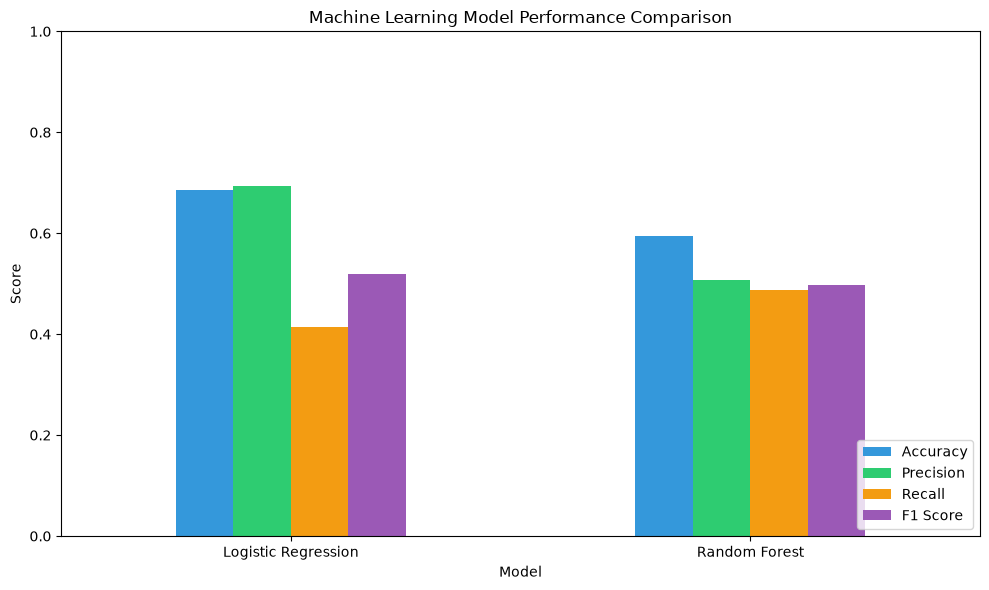

In [ ]:
# Visualize model performance

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

model_results.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(10, 6),
    color=['#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
)

plt.title('Machine Learning Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Confusion Matrix

A confusion matrix is used to examine the classification performance of the machine learning models by showing correct and incorrect predictions for high and low mathematics performance.

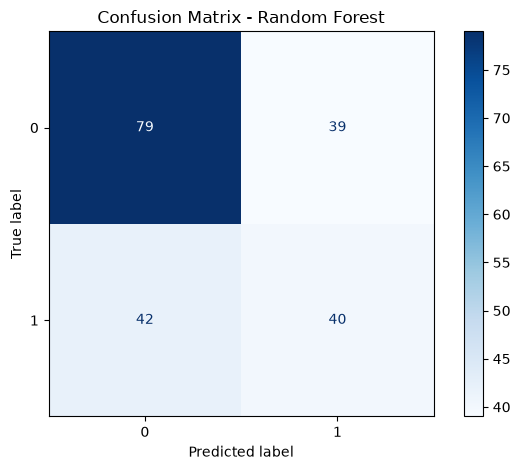

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix for the better-performing model
# We will use Random Forest for now

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap='Blues'
)

plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Feature importance measures how useful each input variable is for the Random Forest model when making predictions.

This analysis helps identify which demographic, socioeconomic, and educational factors contribute most to predicting high mathematics performance.

In [ ]:
# Extract feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                                          Feature  Importance
10                                 lunch_standard    0.156652
11                   test preparation course_none    0.126565
0                                     gender_male    0.120593
4                          race/ethnicity_group E    0.094047
9    parental level of education_some high school    0.070070
5   parental level of education_bachelor's degree    0.069470
3                          race/ethnicity_group D    0.068955
8        parental level of education_some college    0.066936
6         parental level of education_high school    0.064373
2                          race/ethnicity_group C    0.059906
1                          race/ethnicity_group B    0.054874
7     parental level of education_master's degree    0.047560


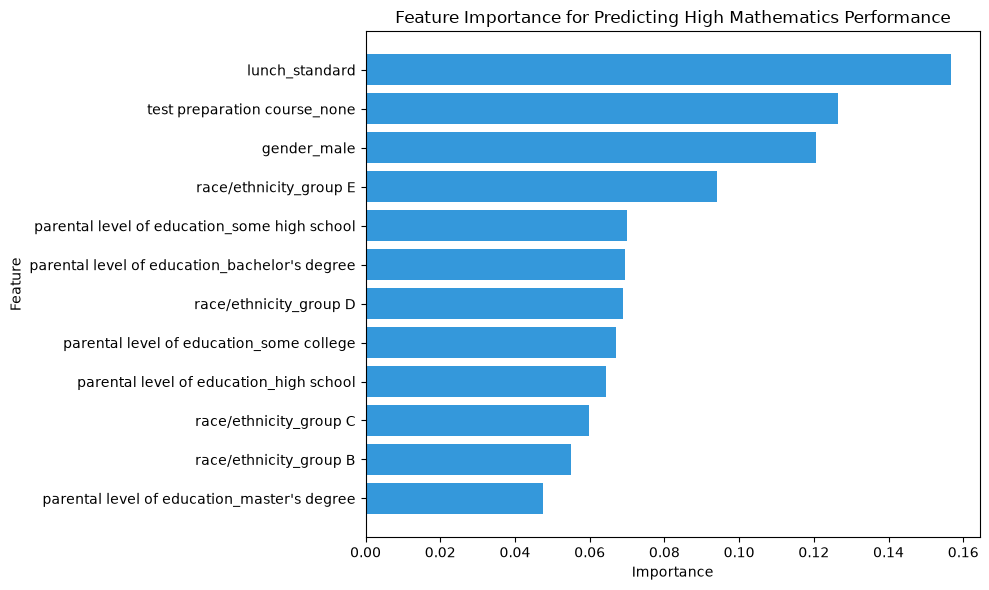

In [ ]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='#3498DB'
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Predicting High Mathematics Performance')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Explainable AI: SHAP Analysis

Machine learning models can make accurate predictions but may be difficult to interpret. SHAP (SHapley Additive exPlanations) is used to understand how individual features influence model predictions.

This analysis helps explain the factors contributing to predictions of high mathematics performance.

In [ ]:
import shap

# Create SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP analysis completed successfully.")

SHAP analysis completed successfully.


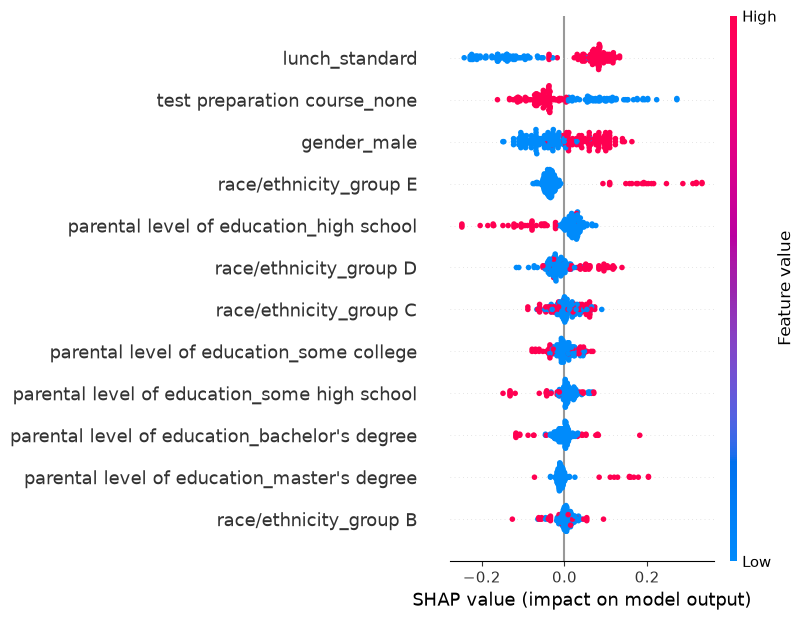

In [ ]:
# SHAP summary plot

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=True
)

## Key Findings

### Statistical Analysis

The independent samples t-test showed a statistically significant difference in mathematics scores between students who completed the test preparation course and those who did not.

The analysis suggests that participation in the test preparation course is associated with differences in mathematics performance.

### Machine Learning Analysis

Two classification models, Logistic Regression and Random Forest, were evaluated for predicting high mathematics performance.

The models were compared using accuracy, precision, recall, and F1 score.

### Model Interpretability

Feature importance and SHAP analysis were used to understand which characteristics contributed most to the model's predictions.

These explainable AI techniques provide insight into the factors associated with high mathematics performance rather than relying only on predictive accuracy.

## Limitations

- The dataset contains 1,000 student records and may not represent students from all populations or educational systems.
- The analysis identifies associations and predictive patterns but does not establish causal relationships.
- The target variable defines high mathematics performance using a threshold of 70, which is a modeling choice.
- The machine learning models use the available demographic, socioeconomic, and educational variables; other potentially important factors may not be included.
- Model performance may change when evaluated on a different dataset.

## Future Research

Future work could incorporate additional factors such as attendance, study time, previous academic performance, and learning behavior.

Longitudinal data could also be used to study how student performance changes over time.

Future studies could explore more advanced machine learning models and investigate whether personalized academic interventions can improve student outcomes.